# **Cacería y pesca**

# **1. Librerías**

In [2]:
suppressMessages({library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)})

# **2. Carga de datos**

In [8]:
caceria_pesca= read.csv("../Data/Reporte_cacería_pesca.csv")
caceria_pesca$Fecha = as.Date(caceria_pesca$Fecha, format = "%Y-%m-%d")

# **3.Análisis de datos**

In [5]:
str(caceria_pesca)

'data.frame':	335 obs. of  33 variables:
 $ X                   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ X_id                : int  443814013 447961711 448081438 448081639 448081748 448081748 448081748 448081798 448122205 448122205 ...
 $ X_uuid              : chr  "27beb75c-f6ed-4a64-b789-a643f6a8cad4" "10a0e2cd-d6b5-4925-b546-3fdce9f289a5" "5518a533-ba1f-41cf-adeb-2f1ac5edeb72" "4d89b121-1a18-47cd-a0d7-7e385901b2ed" ...
 $ X__version__        : chr  "vaixYx97CTWbPsFJAg2ZUu" "vaixYx97CTWbPsFJAg2ZUu" "vaixYx97CTWbPsFJAg2ZUu" "vaixYx97CTWbPsFJAg2ZUu" ...
 $ X_submission_time   : chr  "2025-02-21T18:44:15" "2025-03-04T13:03:54" "2025-03-04T17:57:08" "2025-03-04T17:58:04" ...
 $ X_validation_status : chr  "Approved" "Approved" "Approved" "Approved" ...
 $ timestamp           : int  1741706801 1753051535 1753051654 1753051787 1753051859 1753051859 1753051859 1753051973 1741707072 1741707072 ...
 $ X_submitted_by      : chr  "conservacion_sharamentsa" "conservacion_sharamentsa" "conservacion_shara

## 3.1. Distribución cacería y pesca

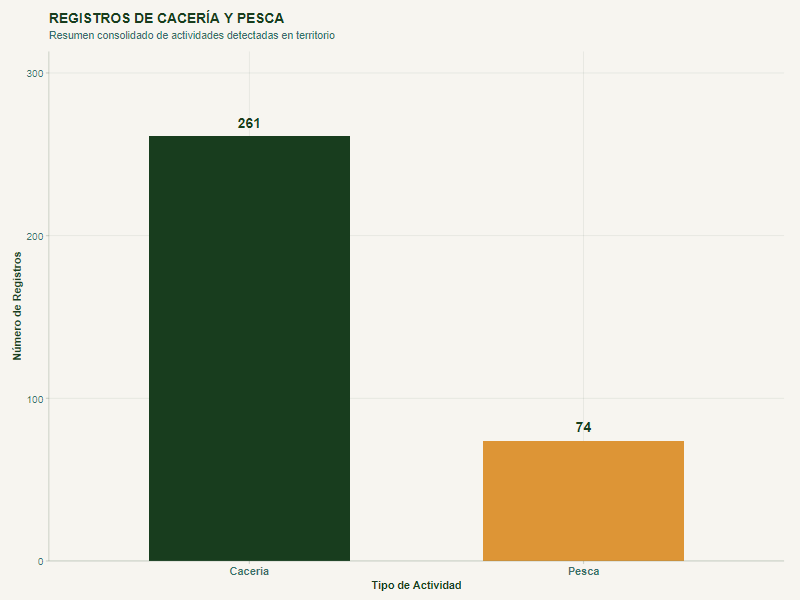

In [16]:
# 1. Preparar y limpiar datos (Asegurando nombres limpios)
resumen_actividades <- caceria_pesca %>%
  mutate(Tipo_actividad = if_else(Tipo_actividad == "Pesca_irregular", "Pesca", Tipo_actividad)) %>%
  group_by(Tipo_actividad) %>%
  summarise(Conteo = n(), .groups = 'drop') %>%
  filter(!is.na(Tipo_actividad) & Tipo_actividad != "")

# 2. Generar la gráfica con estética FP
ggplot(resumen_actividades, aes(x = reorder(Tipo_actividad, -Conteo), y = Conteo, fill = Tipo_actividad)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  
  # Etiquetas de valor (Usando el color 'hoja' para el texto)
  geom_text(aes(label = Conteo), 
            vjust = -0.8, 
            fontface = "bold", 
            size = 5, 
            color = PAL$hoja) +
  
  # Usamos la escala oficial del manual
  scale_fill_pacha() +
  
  # Aplicamos el tema de la Fundación
  theme_pachamama() +
  
  # Ajustes de títulos y escalas
  labs(
    title = "REGISTROS DE CACERÍA Y PESCA",
    subtitle = "Resumen consolidado de actividades detectadas en territorio",
    x = "Tipo de Actividad",
    y = "Número de Registros"
  ) +
  
  # Expandir el eje Y para que no se corten las etiquetas superiores
  scale_y_continuous(expand = expansion(mult = c(0, 0.2))) +
  
  # Toque final: asegurar que el texto del eje X sea legible
  theme(
    axis.text.x = element_text(face = "bold", size = 11)
  )

## 3.2. Cacería y pesca en el tiempo

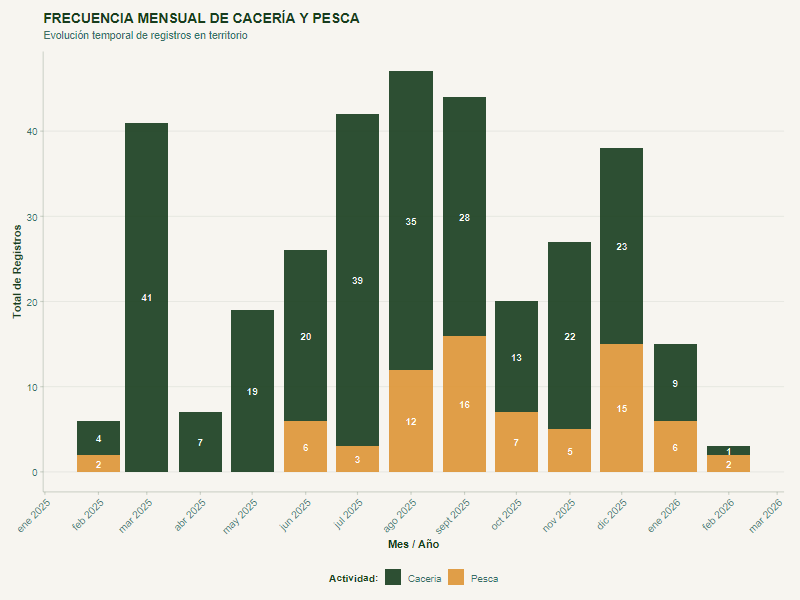

In [17]:
# 1. Preparar los datos con nombres limpios
caceria_conteo_mensual <- caceria_pesca %>%
  mutate(
    # Limpieza de nombres y fechas
    Tipo_actividad = if_else(Tipo_actividad == "Pesca_irregular", "Pesca", Tipo_actividad),
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes, Tipo_actividad) %>%
  summarise(Numero_Registros = n(), .groups = 'drop')

# 2. Generar la gráfica de barras apiladas
ggplot(caceria_conteo_mensual, aes(x = Mes, y = Numero_Registros, fill = Tipo_actividad)) +
  # Barras apiladas con la estética FP (ajustamos el width para que no se solapen)
  geom_col(alpha = 0.9, width = 25, position = "stack") + 
  
  # Etiquetas blancas sobre los segmentos (usando la fuente del tema)
  geom_text(aes(label = Numero_Registros), 
            position = position_stack(vjust = 0.5), 
            color = PAL$blanco, 
            fontface = "bold", 
            size = 3.5) +
  
  # Aplicar escala oficial (Hoja para cacería, Ave para pesca)
  scale_fill_manual(values = c("Caceria" = PAL$hoja, "Pesca" = PAL$ave)) +
  
  # Formateo del eje X alineado al estilo técnico del manual
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  
  # Etiquetas y títulos
  labs(
    title = "FRECUENCIA MENSUAL DE CACERÍA Y PESCA",
    subtitle = "Evolución temporal de registros en territorio",
    x = "Mes / Año",
    y = "Total de Registros",
    fill = "Actividad:"
  ) +
  
  # Aplicar tema base y ajustes específicos
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = PAL$rio),
    panel.grid.major.x = ggplot2::element_blank(), # Limpiamos líneas verticales para mejor lectura
    legend.position = "bottom"
  )

 Ratio Cacería/Pesca

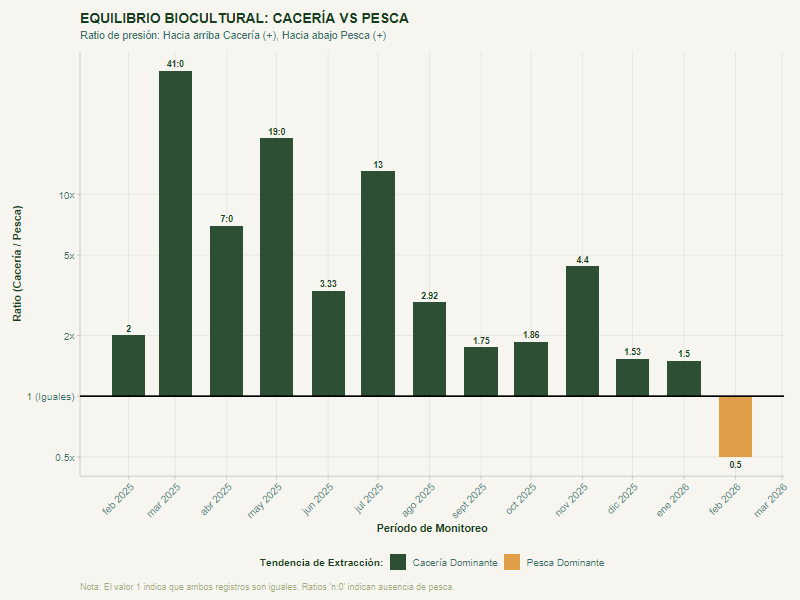

In [23]:
# 1. Preparar datos y calcular Ratio con regla de seguridad
caceria_ratio_data <- caceria_pesca %>%
  mutate(
    Actividad = case_when(
      str_detect(Tipo_actividad, "(?i)caceria") ~ "Caceria",
      str_detect(Tipo_actividad, "(?i)pesca") ~ "Pesca",
      TRUE ~ NA_character_
    ),
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  filter(!is.na(Actividad)) %>%
  group_by(Mes, Actividad) %>%
  summarise(Conteo = n(), .groups = 'drop') %>%
  pivot_wider(names_from = Actividad, values_from = Conteo, values_fill = 0) %>%
  mutate(
    # REGLA: Evitar división para 0. 
    # Si Pesca es 0, usamos el valor de cacería como ratio máximo.
    Ratio_CP = if_else(Pesca == 0, as.numeric(Caceria), Caceria / Pesca),
    
    # Definir dirección para el color (Arriba de 1 = Cacería, Abajo = Pesca)
    Direccion = if_else(Ratio_CP >= 1, "Cacería Dominante", "Pesca Dominante"),
    
    # Etiqueta para mostrar en el gráfico
    Etiqueta = if_else(Pesca == 0, paste0(Caceria, ":0"), round(Ratio_CP, 2) %>% as.character())
  )

# 2. Generar el gráfico con base en el valor 1
ggplot(caceria_ratio_data, aes(x = Mes, y = Ratio_CP, fill = Direccion)) +
  # Dibujamos las barras. Restamos 1 en el geom_col para que partan de la línea base si fuera necesario,
  # pero es más limpio usar escalas transformadas o simplemente dejar que ggplot maneje la base.
  geom_col(alpha = 0.9, width = 20) +
  
  # Línea de referencia en 1 (Equilibrio)
  geom_hline(yintercept = 1, linetype = "solid", color = PAL$negro, linewidth = 0.8) +
  
  # Etiquetas de los valores
  geom_text(aes(label = Etiqueta, vjust = if_else(Ratio_CP >= 1, -0.5, 1.5)), 
            color = PAL$hoja, fontface = "bold", size = 3) +
  
  # Aplicar colores de tu paleta: Hoja para cacería, Ave para pesca
  scale_fill_manual(values = c("Cacería Dominante" = PAL$hoja, "Pesca Dominante" = PAL$ave)) +
  
  # Transformación del eje Y para que la proporción sea simétrica respecto al 1
  scale_y_log10(breaks = c(0.1, 0.5, 1, 2, 5, 10),
                labels = c("0.1x", "0.5x", "1 (Iguales)", "2x", "5x", "10x")) +
  
  # Formateo de fechas
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  
  # Títulos y etiquetas con tu estilo
  labs(
    title = "EQUILIBRIO BIOCULTURAL: CACERÍA VS PESCA",
    subtitle = "Ratio de presión: Hacia arriba Cacería (+), Hacia abajo Pesca (+)",
    x = "Período de Monitoreo",
    y = "Ratio (Cacería / Pesca)",
    fill = "Tendencia de Extracción:",
    caption = "Nota: El valor 1 indica que ambos registros son iguales. Ratios 'n:0' indican ausencia de pesca."
  ) +
  
  # Tu tema oficial
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

## 3.3. Cacería y pesca por comunidad

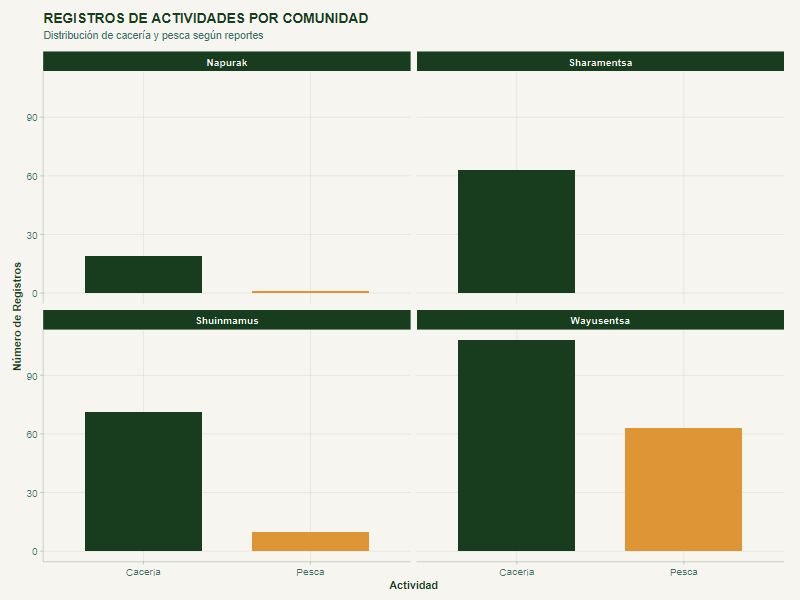

In [14]:

# 1. Preparar los datos agrupados por Comunidad y Tipo de Actividad
datos_facet <- caceria_pesca_ordenado %>%
  group_by(Comunidad, Tipo_actividad) %>%
  summarise(Total = n(), .groups = "drop")

# 2. Crear el gráfico con la identidad visual Pachamama
ggplot(datos_facet, aes(x = Tipo_actividad, y = Total, fill = Tipo_actividad)) +
  # Geometría de barras
  geom_col(show.legend = FALSE, width = 0.7) +
  # Facet wrap por comunidad
  facet_wrap(~ Comunidad) + 
  # Aplicar la escala de colores cualitativa del manual
  scale_fill_pacha() +
  # Aplicar el tema oficial definido en plot_themes.R
  theme_pachamama() +
  # Etiquetas informativas
  labs(
    title = "REGISTROS DE ACTIVIDADES POR COMUNIDAD",
    subtitle = "Distribución de cacería y pesca según reportes",
    x = "Actividad",
    y = "Número de Registros"
  ) +
  # Ajuste adicional para que el texto de X no se amontone si hay muchos datos
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5)
  )

## 3.4. Porcentaje

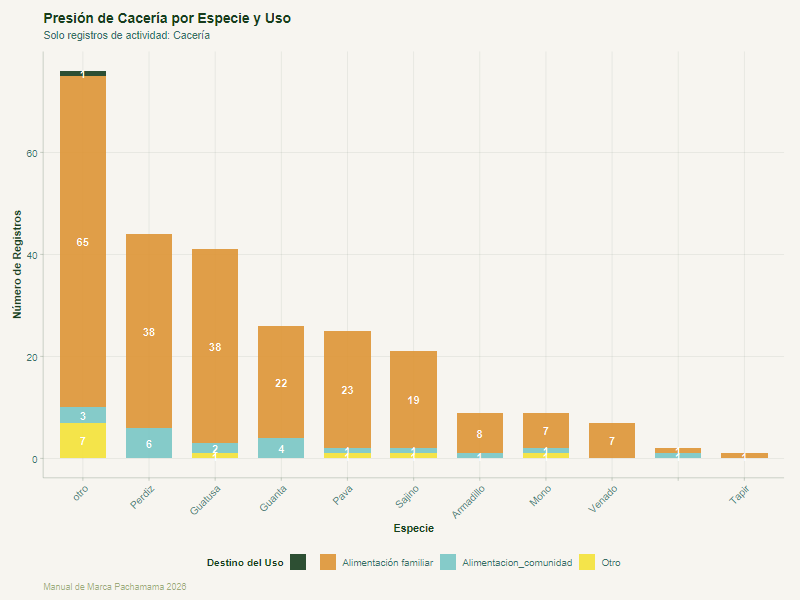

In [24]:

# 1. Filtrar y preparar los datos
caceria_especies_uso <- caceria_pesca %>%
  # Filtramos solo por Cacería
  filter(Tipo_actividad == "Caceria") %>%
  # Limpiamos NAs para que no ensucien la gráfica
  mutate(
    Especie = replace_na(Especie, "No especificado"),
    Uso_caceria = replace_na(Uso_caceria, "Uso no registrado")
  ) %>%
  group_by(Especie, Uso_caceria) %>%
  summarise(Conteo = n(), .groups = 'drop')

# 2. Generar el gráfico de barras apiladas
ggplot(caceria_especies_uso, aes(x = reorder(Especie, -Conteo, sum), y = Conteo, fill = Uso_caceria)) +
  # Barras apiladas
  geom_col(alpha = 0.9, width = 0.7) +
  # Etiquetas de valor sobre cada segmento
  geom_text(aes(label = Conteo), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 4) +
  # Paleta institucional
  scale_fill_pacha() + 
  labs(
    title = "Presión de Cacería por Especie y Uso",
    subtitle = "Solo registros de actividad: Cacería",
    x = "Especie",
    y = "Número de Registros",
    fill = "Destino del Uso",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

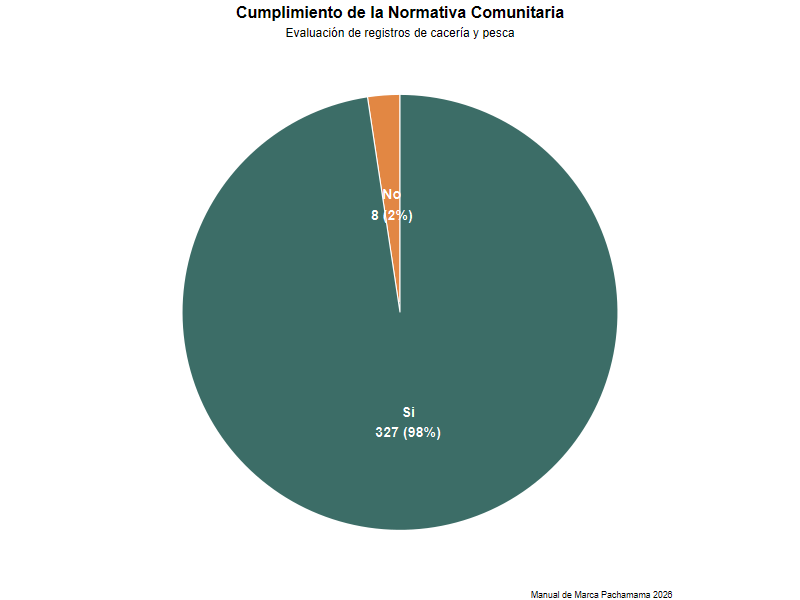

In [26]:


# 1. Preparar los datos: Calcular totales y porcentajes
resumen_normativa <- caceria_pesca %>%
  filter(!is.na(Cumplio_normativa)) %>%
  group_by(Cumplio_normativa) %>%
  summarise(Total = n(), .groups = 'drop') %>%
  mutate(
    Porcentaje = Total / sum(Total),
    Etiqueta = paste0(Cumplio_normativa, "\n", Total, " (", percent(Porcentaje, accuracy = 1), ")")
  )

# 2. Generar el Gráfico de Pastel
ggplot(resumen_normativa, aes(x = "", y = Porcentaje, fill = Cumplio_normativa)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  # Convertir a coordenadas polares para que sea un círculo
  coord_polar("y", start = 0) +
  # Añadir etiquetas internas
  geom_text(aes(label = Etiqueta), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 5) +
  # Colores: Verde para cumplimiento, Naranja/Rojo para incumplimiento
  scale_fill_manual(values = c("Si" = "#3c6d67", "No" = "#e28743")) +
  labs(
    title = "Cumplimiento de la Normativa Comunitaria",
    subtitle = "Evaluación de registros de cacería y pesca",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_void() + # Limpia ejes y cuadrículas para un look de pastel puro
  theme(
    legend.position = "none", # Quitamos la leyenda porque la info ya está en el pastel
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    plot.subtitle = element_text(hjust = 0.5, size = 12)
  )